# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import pickle
import warnings
warnings.filterwarnings('ignore')

# Load Dataset

In [2]:
rfm = pd.read_csv('../data/processed/rfm_data.csv')
print(f"Loaded: {rfm.shape}")
rfm.head(3)

Loaded: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,19880.9957
1,12347,2,7,4310.0000
2,12348,75,4,1797.2400


In [3]:
# Clustering uses distances — scaling is mandatory

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# Save scaler — needed later in the app
with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Features scaled ✓")
print(f"Mean after scaling (should be ~0): {rfm_scaled.mean(axis=0).round(3)}")
print(f"Std after scaling  (should be ~1): {rfm_scaled.std(axis=0).round(3)}")

Features scaled ✓
Mean after scaling (should be ~0): [ 0. -0.  0.]
Std after scaling  (should be ~1): [1. 1. 1.]


# Elbow Method - K

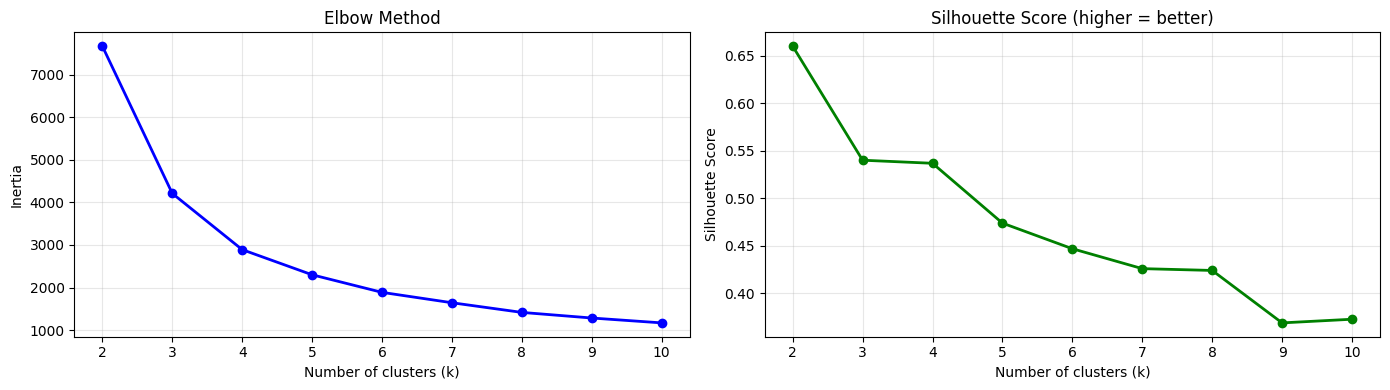


k | Inertia     | Silhouette
-----------------------------------
2 |     7665.3  | 0.6602
3 |     4208.4  | 0.5400
4 |     2888.6  | 0.5367
5 |     2298.6  | 0.4737
6 |     1885.9  | 0.4467
7 |     1642.2  | 0.4257
8 |     1415.3  | 0.4238
9 |     1283.9  | 0.3685
10 |     1169.5  | 0.3724


In [4]:
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(rfm_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2)
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouettes, 'go-', linewidth=2)
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score (higher = better)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/elbow_silhouette.png', dpi=150)
plt.show()

# Print the scores table
print("\nk | Inertia     | Silhouette")
print("-" * 35)
for k, i, s in zip(K_range, inertias, silhouettes):
    print(f"{k} | {i:10.1f}  | {s:.4f}")

In [6]:
# k=5 matches our 5 business segments perfectly:
# Champions, Loyal, New, At Risk, Lost
# (if k=4 or k=6 looks clearly better from your plots, use that instead)

BEST_K = 5

kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Save the model
with open('../models/kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

print(f"K-Means fitted with k={BEST_K} ✓")
print(f"Model saved to models/kmeans_model.pkl ✓")
print(f"\nCluster sizes:")
print(rfm['Cluster'].value_counts().sort_index())

K-Means fitted with k=5 ✓
Model saved to models/kmeans_model.pkl ✓

Cluster sizes:
Cluster
0    2250
1     793
2     206
3    1014
4      75
Name: count, dtype: int64


In [7]:
# Get cluster centers in original scale to understand each group
centers = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers, 
                           columns=['Recency','Frequency','Monetary'])
centers_df.index.name = 'Cluster'
print("Cluster centers (original scale):")
print(centers_df.round(1))

# Map each cluster number to a business label
# Strategy: sort by Recency ASC, Monetary DESC to rank them
# We'll assign labels based on center values

centers_df['Cluster'] = centers_df.index
centers_df = centers_df.sort_values('Monetary', ascending=False)
print("\nSorted by Monetary (highest spenders first):")
print(centers_df[['Recency','Frequency','Monetary']].round(1))

Cluster centers (original scale):
         Recency  Frequency  Monetary
Cluster                              
0           52.4        2.2     711.8
1           28.1        7.1    2732.1
2           16.7       16.5    6639.9
3          253.0        1.5     445.2
4           17.8       23.4   17990.4

Sorted by Monetary (highest spenders first):
         Recency  Frequency  Monetary
Cluster                              
4           17.8       23.4   17990.4
2           16.7       16.5    6639.9
1           28.1        7.1    2732.1
0           52.4        2.2     711.8
3          253.0        1.5     445.2


In [11]:
# Champions = low recency, high freq, high monetary
# Lost = high recency, low freq, low monetary

# This mapping will differ 
segment_map = {
    4: 'Champions',
    2: 'Loyal Customers',
    1: 'Potential Loyalists',
    0: 'At Risk',
    3: 'Lost Customers'
}

rfm['Segment'] = rfm['Cluster'].map(segment_map)

print("Segment distribution:")
print(rfm['Segment'].value_counts())
print("\nSegment averages:")
print(rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round(1))


Segment distribution:
Segment
At Risk                2250
Lost Customers         1014
Potential Loyalists     793
Loyal Customers         206
Champions                75
Name: count, dtype: int64

Segment averages:
                     Recency  Frequency  Monetary
Segment                                          
At Risk                 52.4        2.2     710.9
Champions               17.8       23.4   17990.4
Lost Customers         253.0        1.5     445.2
Loyal Customers         16.7       16.5    6639.9
Potential Loyalists     28.0        7.1    2732.2


# Visuals

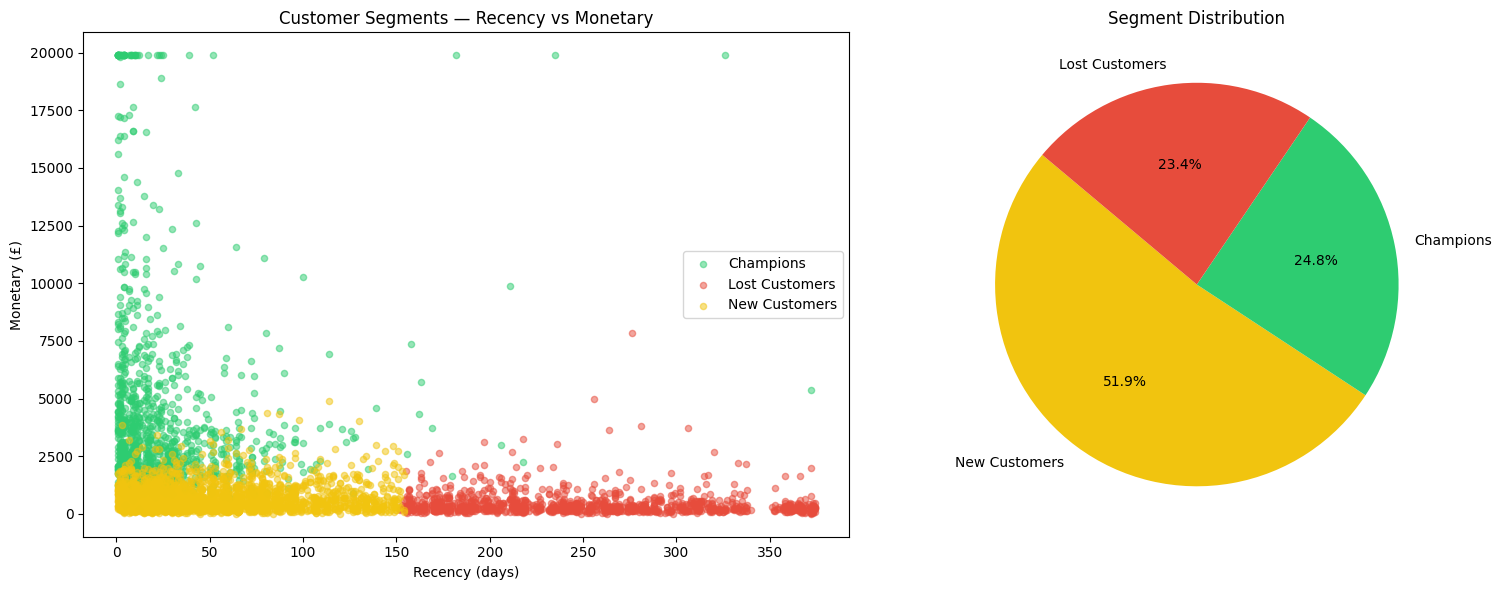

In [9]:
colors = {
    'Champions':       '#2ecc71',
    'Loyal Customers': '#3498db',
    'New Customers':   '#f1c40f',
    'At Risk':         '#e67e22',
    'Lost Customers':  '#e74c3c'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: Recency vs Monetary
for seg, grp in rfm.groupby('Segment'):
    axes[0].scatter(grp['Recency'], grp['Monetary'],
                    label=seg, alpha=0.5, s=20,
                    color=colors.get(seg, 'gray'))
axes[0].set_xlabel('Recency (days)')
axes[0].set_ylabel('Monetary (£)')
axes[0].set_title('Customer Segments — Recency vs Monetary')
axes[0].legend()

# Pie chart
seg_counts = rfm['Segment'].value_counts()
axes[1].pie(seg_counts, labels=seg_counts.index,
            autopct='%1.1f%%',
            colors=[colors.get(s,'gray') for s in seg_counts.index],
            startangle=140)
axes[1].set_title('Segment Distribution')

plt.tight_layout()
plt.savefig('../reports/segments_plot.png', dpi=150)
plt.show()

# DBSCAN - Comparison

In [10]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.5, min_samples=5)
db_labels = db.fit_predict(rfm_scaled)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise    = list(db_labels).count(-1)

print(f"DBSCAN found {n_clusters} clusters")
print(f"Noise points (outliers): {n_noise} ({n_noise/len(rfm)*100:.1f}%)")

if n_clusters > 1:
    # Only score non-noise points
    mask = db_labels != -1
    db_score = silhouette_score(rfm_scaled[mask], db_labels[mask])
    km_score = silhouette_score(rfm_scaled, rfm['Cluster'])
    print(f"\nSilhouette — K-Means : {km_score:.4f}")
    print(f"Silhouette — DBSCAN  : {db_score:.4f}")
    print(f"\nWinner: {'K-Means' if km_score > db_score else 'DBSCAN'}")
else:
    print("DBSCAN couldn't form clusters with these settings")
    print("This is normal — RFM data is not density-based")
    print("K-Means wins for this use case ✓")

DBSCAN found 8 clusters
Noise points (outliers): 60 (1.4%)

Silhouette — K-Means : 0.4737
Silhouette — DBSCAN  : 0.6451

Winner: DBSCAN


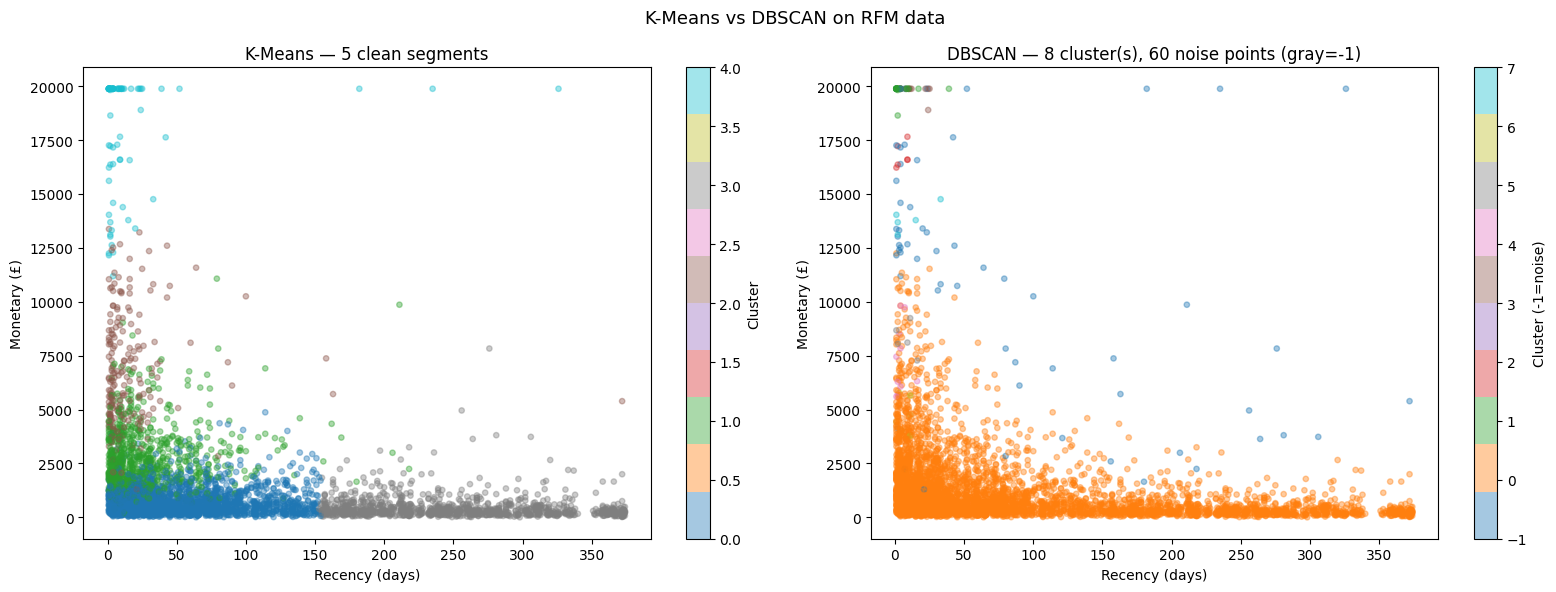

This visual proves WHY K-Means wins for RFM data.
DBSCAN is designed for arbitrary-shaped dense blobs — RFM is a gradient, not blobs.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K-Means plot
scatter1 = axes[0].scatter(rfm['Recency'], rfm['Monetary'],
                            c=rfm['Cluster'], cmap='tab10',
                            alpha=0.4, s=15)
axes[0].set_title('K-Means — 5 clean segments')
axes[0].set_xlabel('Recency (days)')
axes[0].set_ylabel('Monetary (£)')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# DBSCAN plot
scatter2 = axes[1].scatter(rfm['Recency'], rfm['Monetary'],
                            c=db_labels, cmap='tab10',
                            alpha=0.4, s=15)
axes[1].set_title(f'DBSCAN — {n_clusters} cluster(s), {n_noise} noise points (gray=-1)')
axes[1].set_xlabel('Recency (days)')
axes[1].set_ylabel('Monetary (£)')
plt.colorbar(scatter2, ax=axes[1], label='Cluster (-1=noise)')

plt.suptitle('K-Means vs DBSCAN on RFM data', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/kmeans_vs_dbscan.png', dpi=150)
plt.show()

print("This visual proves WHY K-Means wins for RFM data.")
print("DBSCAN is designed for arbitrary-shaped dense blobs — RFM is a gradient, not blobs.")

In [13]:
rfm.to_csv('../data/processed/rfm_labeled.csv', index=False)
print(f"Saved rfm_labeled.csv ✓")
print(f"\nFinal segment summary:")
print(rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round(1))
print("\nDay 3 complete! Ready for Autoencoder.")

Saved rfm_labeled.csv ✓

Final segment summary:
                     Recency  Frequency  Monetary
Segment                                          
At Risk                 52.4        2.2     710.9
Champions               17.8       23.4   17990.4
Lost Customers         253.0        1.5     445.2
Loyal Customers         16.7       16.5    6639.9
Potential Loyalists     28.0        7.1    2732.2

Day 3 complete! Ready for Autoencoder.
